In [6]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers, optimizers
from tensorflow.keras.layers import Conv2D, Dense, GlobalAveragePooling2D, Dropout, Flatten, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import Xception
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
print(tf.__version__)

2.16.2


In [3]:
from PIL import Image, ImageFile
train_dir = 'Dataset/Train'
validation_dir = 'Dataset/Validation'
test_dir = 'Dataset/Test'
# Ensure that truncated images are handled correctly
ImageFile.LOAD_TRUNCATED_IMAGES = True

class SafeImageDataGenerator(ImageDataGenerator):
    def _get_batches_of_transformed_samples(self, index_array):
        batch_x = []
        batch_y = []
        for i, j in enumerate(index_array):
            try:
                img = load_img(self.filepaths[j], target_size=self.target_size)
                img_array = img_to_array(img)
                batch_x.append(img_array)
                batch_y.append(self.labels[j])
            except Exception as e:
                print(f"Skipped corrupted image: {self.filepaths[j]}")
                continue
        return np.array(batch_x), np.array(batch_y)

In [4]:
# Data Augmentation for Training Set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No Augmentation for Validation and Test Sets
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


In [5]:
# Create image data generators for training, validation, and testing with categorical labels.
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')
validation_generator = validation_datagen.flow_from_directory(validation_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')

Found 20000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


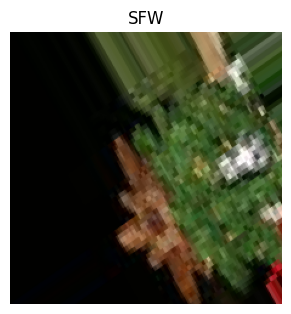

In [5]:
#Be Careful while running the code, images may be NSFW
def plot_images(generator, class_names, num_images=1):
    # Get a batch of images and labels
    images, labels = next(generator)
    
    # Plot images
    plt.figure(figsize=(12, 12))
    for i in range(num_images):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis('off')
    plt.show()

# Get class names from the generator
class_names = list(train_generator.class_indices.keys())

# Plot some sample images from the training generator
plot_images(train_generator, class_names)

In [7]:
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model initially
base_model.trainable = False


In [5]:
base_model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 111, 111, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_bn               │ (None, 111, 111, 32)      │             128 │ block1_conv1[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_act (Activation) │ (None, 111, 111, 32)      │               0 │ block1_conv1_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 109, 109, 64)      │          18,432 │ block1_conv1_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_bn               │ (None, 109, 109, 64)      │             256 │ block1_conv2[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_act (Activation) │ (None, 109, 109, 64)      │               0 │ block1_conv2_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1               │ (None, 109, 109, 128)     │           8,768 │ block1_conv2_act[0][0]     │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1_bn            │ (None, 109, 109, 128)     │             512 │ block2_sepconv1[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_act           │ (None, 109, 109, 128)     │               0 │ block2_sepconv1_bn[0][0]   │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2               │ (None, 109, 109, 128)     │          17,536 │ block2_sepconv2_act[0][0]  │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_bn            │ (None, 109, 109, 128)     │             512 │ block2_sepconv2[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 55, 55, 128)       │           8,192 │ block1_conv2_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 55, 55, 128)       │               

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,861,480 (79.58 MB)

In [8]:
#Define the model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(2, activation='softmax') 
])

In [9]:
#Compile the model
model.compile(optimizer=optimizers.Adam(learning_rate=0.00001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [10]:
#Set callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [11]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/5


C:\Users\dhanu\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 1100s 2s/step - accuracy: 0.5938 - loss: 2.3358 - val_accuracy: 0.9360 - val_loss: 1.5327 - learning_rate: 1.0000e-05
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 982s 2s/step - accuracy: 0.7936 - loss: 1.8082 - val_accuracy: 0.9500 - val_loss: 1.4596 - learning_rate: 1.0000e-05
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 981s 2s/step - accuracy: 0.8438 - loss: 1.7075 - val_accuracy: 0.9572 - val_loss: 1.4342 - learning_rate: 1.0000e-05
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1024s 2s/step - accuracy: 0.8700 - loss: 1.6525 - val_accuracy: 0.9582 - val_loss: 1.4211 - learning_rate: 1.0000e-05
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1011s 2s/step - accuracy: 0.8813 - loss: 1.6181 - val_accuracy: 0.9597 - val_loss: 1.4106 - learning_rate: 1.0000e-05


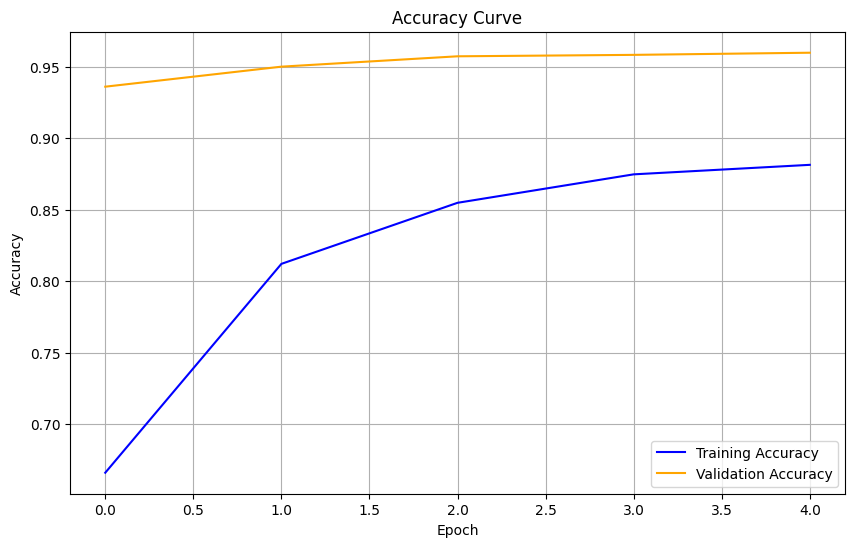

In [12]:
#Plotting the accuracy curve
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plotting the accuracy curves
plt.figure(figsize=(10, 6))
plt.plot(accuracy, label='Training Accuracy', color='blue')
plt.plot(val_accuracy, label='Validation Accuracy', color='orange')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Unfreeze last 30 layers for fine-tuning
for layer in base_model.layers[-30:]:
    layer.trainable = True


In [14]:
# Re-compile the model with a lower learning rate
model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [15]:
# Continue training with fine-tuning
history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1388s 2s/step - accuracy: 0.8536 - loss: 1.6580 - val_accuracy: 0.9535 - val_loss: 1.4112 - learning_rate: 1.0000e-05
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1347s 2s/step - accuracy: 0.9093 - loss: 1.5431 - val_accuracy: 0.9588 - val_loss: 1.3874 - learning_rate: 1.0000e-05
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1330s 2s/step - accuracy: 0.9232 - loss: 1.5039 - val_accuracy: 0.9670 - val_loss: 1.3653 - learning_rate: 1.0000e-05
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1330s 2s/step - accuracy: 0.9295 - loss: 1.4720 - val_accuracy: 0.9712 - val_loss: 1.3451 - learning_rate: 1.0000e-05
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1330s 2s/step - accuracy: 0.9317 - loss: 1.4465 - val_accuracy: 0.9682 - val_loss: 1.3424 - learning_rate: 1.0000e-05


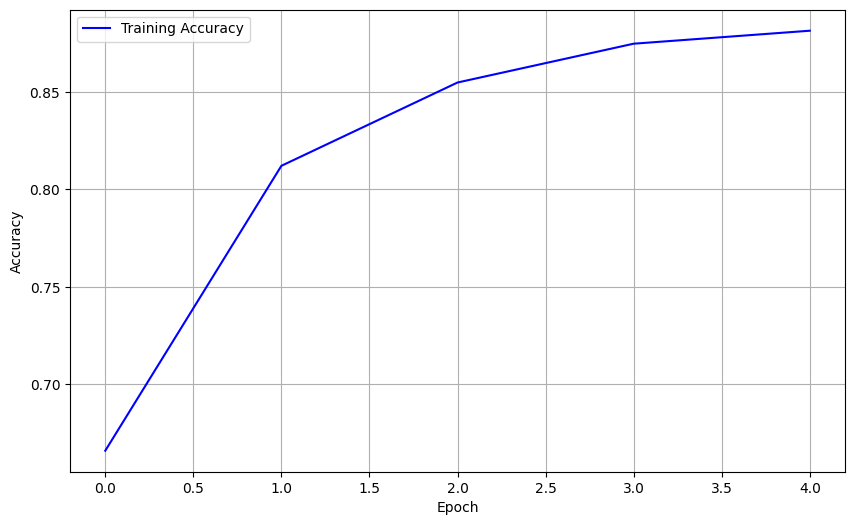

In [20]:
#Plotting the accuracy curve
accuracy = history.history['accuracy']

# Plotting the accuracy curves
plt.figure(figsize=(10, 6))
plt.plot(accuracy, label='Training Accuracy', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
test_loss, test_accuracy = model.evaluate(test_generator, steps=len(test_generator))

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

125/125 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9096 - loss: 1.4953
Test Loss: 1.4837
Test Accuracy: 0.9128


In [18]:
model.save('Xception_NSFW_model.keras')

In [19]:
model.save('Xception_NSFW_model.h5')

In [21]:
from tensorflow.keras.preprocessing import image
import numpy as np

def preprocess_image(img_path):
    # Load the image
    img = image.load_img(img_path, target_size=(224, 224))  # Ensure the target size matches your model's input
    
    # Convert the image to a numpy array
    img_array = image.img_to_array(img)
    
    # Expand dimensions to match the expected input shape (1, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Rescale the image (if necessary, e.g., divide by 255)
    img_array = img_array / 255.0
    
    return img_array


In [22]:
def predict_image(img_path):
    # Preprocess the image
    img_array = preprocess_image(img_path)
    
    # Make a prediction
    prediction = model.predict(img_array)
    
    # Get the index of the class with the highest probability
    predicted_class = np.argmax(prediction, axis=1)
    print(prediction)
    return predicted_class[0]

# Predict on an image
img_path = 'Dataset/Train/NSFW/00a3ce1da9c77535b357c4732e21697bf97f6cdfc2561f610172d1c0b6fbb8b9.jpg'
predicted_class = predict_image(img_path)

# Assuming class 0 is SFW and class 1 is NSFW
if predicted_class == 0:
    print("The image is NSFW.")
else:
    print("The image is SFW.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 843ms/step
[[0.9705095  0.02949041]]
The image is NSFW.
